In [2]:
import os 
import numpy as np


In [12]:
def load_calibrator():
    import pickle 
    
    regressor_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/processed/general/supplementary_5/residuals_analysis_new_dataset_locscale_222/regressor_isotonic_seed_42.pickle"
    calibrator = pickle.load(open(regressor_path, "rb"))
    
    return calibrator
def calibrate_variance(variance_map):
    from locscale.emmernet.utils import load_calibrator
    
    calibrator = load_calibrator()
    input_map_shape = variance_map.shape
    calibrated_variance_map = calibrator.predict(variance_map.flatten()).reshape(input_map_shape)
    
    return calibrated_variance_map


def calculate_significance_map_from_emmernet_output(locscale_output_path, mean_prediction_path, var_prediction_path, n_samples=15):
    from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
    from scipy.stats import norm
    import os
    import warnings
    # filter out warnings
    warnings.filterwarnings("ignore")
    # compute the z score map 
    locscale_map, apix = load_map(locscale_output_path)
    mean_prediction, apix = load_map(mean_prediction_path)
    var_prediction, apix = load_map(var_prediction_path)
    # save a chimera script at the same folder as mean_prediction
    main_folder = os.path.dirname(mean_prediction_path)
    chimera_script_path = os.path.join(main_folder, "chimera_script.cxc")
    standard_deviation = np.sqrt(var_prediction)
    standard_error = standard_deviation / np.sqrt(n_samples)
    
    standard_error_calibrated = calibrate_variance(standard_error)

    z_score_map = (mean_prediction - locscale_map) / standard_error_calibrated

    # take care of nan values
    z_score_map[np.isnan(z_score_map)] = 100 # make it a large number so that is is very significant
    # convert the z score map to a p value map

    cdf_map = norm.cdf(z_score_map)
    # renormalize to -100 and 100
    pVDDT_map = cdf_map * 200 - 100
    
    
    output_folder = os.path.dirname(locscale_output_path)
    # get the filename of mean_prediction_path to add as a prefix to the output files
    mean_prediction_filename = os.path.basename(mean_prediction_path).split('.')[0]
    pVDDT_map_path = os.path.join(output_folder, f"{mean_prediction_filename}_pVDDT_new.mrc")
    #z_score_map_path = os.path.join(output_folder, f"{mean_prediction_filename}_z_scores_calibrated.mrc")

    save_as_mrc(pVDDT_map, pVDDT_map_path, apix)
    #save_as_mrc(z_score_map, z_score_map_path, apix)


In [13]:
fe_parent_dir = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/feature_enhance_test_maps_hybrid_60k"
emdb_pdb_list = [x for x in os.listdir(fe_parent_dir) if os.path.isdir(os.path.join(fe_parent_dir, x))]

for emdb_pdb in emdb_pdb_list:
    print(f"Processing {emdb_pdb}...")
    emdb, pdb = emdb_pdb.split("_")
    emdb_dir = os.path.join(fe_parent_dir, emdb_pdb)
    fe_map_path = os.path.join(emdb_dir, f"emd_{emdb}_emmernet_output_mean.mrc")
    baseline_map_path = os.path.join(emdb_dir, f"emd_{emdb}_emmernet_output_locscale_output.mrc")
    variance_map_path = os.path.join(emdb_dir, f"emd_{emdb}_emmernet_output_var.mrc")
    calculate_significance_map_from_emmernet_output(
        locscale_output_path=baseline_map_path, 
        mean_prediction_path=fe_map_path, 
        var_prediction_path=variance_map_path, 
        n_samples=15
    )


Processing 0282_6huo...


Processing 0311_6hz5...
Processing 0560_6nzu...
Processing 10365_6t23...
Processing 20220_6oxl...
Processing 20226_6p07...
Processing 3545_5mqf...
Processing 4141_5m1s...
Processing 4531_6qdw...
Processing 4571_6qk7...
Processing 4997_6rtc...
Processing 7127_6bpq...
Processing 8702_5vkq...
Processing 9610_6adq...


In [ ]:
locscale_map = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/check_calibration_using_broad_dataset/emd_3061/emd_3061_feature_enhance_fulldataset_30epoch_locscale_output.mrc"
mean_prediction = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/check_calibration_using_broad_dataset/emd_3061/emd_3061_feature_enhance_fulldataset_30epoch_mean.mrc"
var_prediction = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/check_calibration_using_broad_dataset/emd_3061/emd_3061_feature_enhance_fulldataset_30epoch_var.mrc"
old_pvddt_inverted_map = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/check_calibration_using_broad_dataset/emd_3061/hallucinations_probabilities_map.mrc"

calculate_significance_map_from_emmernet_output(
    locscale_output_path=locscale_map, 
    mean_prediction_path=mean_prediction, 
    var_prediction_path=var_prediction, 
    n_samples=15
)

In [14]:
fe_parent_dir = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration"
emdb_list = [x.split("_")[1] for x in os.listdir(fe_parent_dir) if os.path.isdir(os.path.join(fe_parent_dir, x))]

for emdb in emdb_list:
    print(f"Processing {emdb}...")
    emdb_dir = os.path.join(fe_parent_dir, f"emd_{emdb}")
    fe_map_path = os.path.join(emdb_dir, f"emd_{emdb}_feature_enhanced_map.mrc")
    baseline_map_path = os.path.join(emdb_dir, f"emd_{emdb}_baseline_map.mrc")
    variance_map_path = os.path.join(emdb_dir, f"emd_{emdb}_variance_map.mrc")
    if not (os.path.exists(fe_map_path) and os.path.exists(baseline_map_path) and os.path.exists(variance_map_path)):
        print(f"Missing files for {emdb}, skipping...")
        continue
    calculate_significance_map_from_emmernet_output(
        locscale_output_path=baseline_map_path, 
        mean_prediction_path=fe_map_path, 
        var_prediction_path=variance_map_path, 
        n_samples=15
    )


Processing 34653...
Processing 35402...
Processing 27395...
Processing 15631...
Processing 26867...
Processing 28536...
Processing 33481...
Processing 29291...
Processing 26563...
Processing 15948...
Processing 15589...
Processing 28153...
Processing 26071...
Processing 28666...
Processing 28962...


In [15]:
# get a correlation of the old pVDDT inverted map with the new pVDDT map
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
import matplotlib.pyplot as plt
import seaborn as sns

pvddt_values = {}

fe_parent_dir = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration"
emdb_list = [x.split("_")[1] for x in os.listdir(fe_parent_dir) if os.path.isdir(os.path.join(fe_parent_dir, x))]

for emdb in emdb_list:
    print(f"Processing {emdb}...")
    emdb_dir = os.path.join(fe_parent_dir, f"emd_{emdb}")
    fe_map_path = os.path.join(emdb_dir, f"emd_{emdb}_feature_enhanced_map.mrc")
    baseline_map_path = os.path.join(emdb_dir, f"emd_{emdb}_baseline_map.mrc")
    variance_map_path = os.path.join(emdb_dir, f"emd_{emdb}_variance_map.mrc")
    old_inverted_pvddt_map_path = os.path.join(emdb_dir, f"emd_{emdb}_pvddt.mrc")
    new_pvddt_map_path = os.path.join(emdb_dir, f"emd_{emdb}_feature_enhanced_map_pVDDT_new.mrc")

    old_pvddt_inverted, apix = load_map(old_inverted_pvddt_map_path)
    new_pvddt, apix = load_map(new_pvddt_map_path)
    mean_map, apix = load_map(fe_map_path)

    old_pvddt = old_pvddt_inverted * -1
    #save_as_mrc(old_pvddt, old_inverted_pvddt_map_path.replace("pvddt", "pvddt_corrected"), apix)
    masked_mean_map = mean_map > 0.1 # calibration region 

    n_sample = 5000 # choose 500 random points from the masked mean map
    voxels_to_sample = np.where(masked_mean_map)
    sampled_indices = np.random.choice(len(voxels_to_sample[0]), size=n_sample, replace=False)

    sampled_old_pvddt = old_pvddt[voxels_to_sample][sampled_indices]
    sampled_new_pvddt = new_pvddt[voxels_to_sample][sampled_indices]
    pvddt_values[emdb] = {
        "old": sampled_old_pvddt,
        "new": sampled_new_pvddt
    }




Processing 34653...
Processing 35402...
Processing 27395...
Processing 15631...
Processing 26867...
Processing 28536...
Processing 33481...
Processing 29291...
Processing 26563...
Processing 15948...
Processing 15589...
Processing 28153...
Processing 26071...
Processing 28666...
Processing 28962...


Text(0.5, 1.0, 'Correlation between old and new pVDDT values')

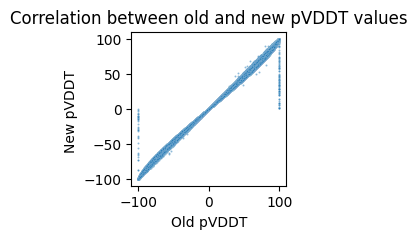

In [16]:
# plot the correlation between old and new pVDDT values
all_old_pvddt = np.concatenate([pvddt_values[emdb]["old"] for emdb in emdb_list])
all_new_pvddt = np.concatenate([pvddt_values[emdb]["new"] for emdb in emdb_list])
plt.figure(figsize=(2, 2))
sns.scatterplot(x=all_old_pvddt, y=all_new_pvddt, alpha=0.5, s=2)
plt.xlabel("Old pVDDT")
plt.ylabel("New pVDDT ")
plt.title("Correlation between old and new pVDDT values")



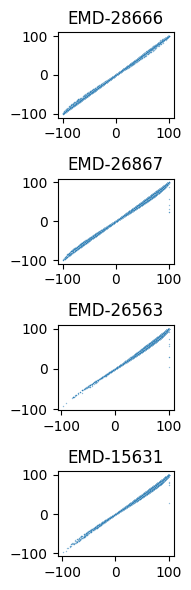

In [17]:
from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42
n_plots = 4
fig, axes = plt.subplots(4, 1, figsize=(2, 6))
emdb_plot = ["28666", "26867", "26563", "15631"]
for i, emdb in enumerate(emdb_plot):
    ax = axes[i]
    old_pvddt = pvddt_values[emdb]["old"]
    new_pvddt = pvddt_values[emdb]["new"]
    sns.scatterplot(x=old_pvddt, y=new_pvddt, alpha=0.5, s=1, ax=ax)
    # hide all axis
    ax.set_xlabel("")
    ax.set_ylabel("")
    # hide ticks
    #ax.set_xticks([])
    #ax.set_yticks([])
    ax.set_title(f"EMD-{emdb}")

fig.tight_layout()
fig.savefig("/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/larger_dataset/testing_calibration/old_vs_new_pvddt_correlation_2.pdf", dpi=600)